In [6]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
dengue = pd.read_csv('dengbr22.csv')

C:\Users\Lua.LUADESKTOP\AppData\Local\Temp\ipykernel_10348\3970577942.py:4: DtypeWarning: Columns (44,46,54,101) have mixed types. Specify dtype option on import or set low_memory=False.
  dengue = pd.read_csv('dengbr22.csv')


In [7]:
dengue.columns

Index(['TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'SEM_NOT', 'NU_ANO', 'SG_UF_NOT',
       'ID_MUNICIP', 'ID_REGIONA', 'ID_UNIDADE', 'DT_SIN_PRI',
       ...
       'EVIDENCIA', 'PLAQ_MENOR', 'CON_FHD', 'COMPLICA', 'TP_SISTEMA',
       'NDUPLIC_N', 'DT_DIGITA', 'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W'],
      dtype='object', length=121)

<b>Registros por meses</b>: Estudo de contagem de quantas vezes o mês de notificação é registrado, baseado na contagem total de UF. 

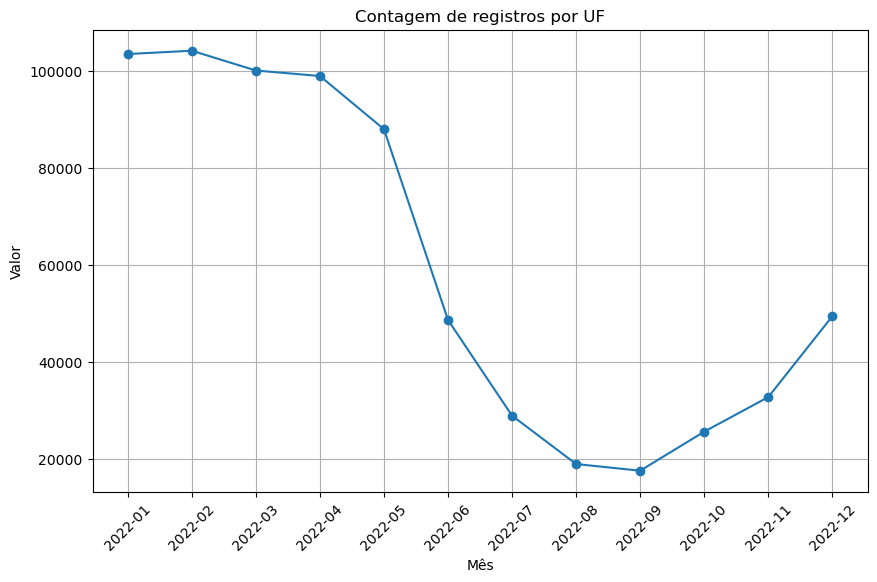

In [8]:
dengue['DT_NOTIFIC'] #Data da notificação
dengue['DT_NOTIFIC'] = pd.to_datetime(dengue['DT_NOTIFIC'])

dengue['dengue_notifi_mes'] = dengue['DT_NOTIFIC'].dt.to_period('M')  #Extrair mês
notifi_por_uf = dengue.groupby('dengue_notifi_mes')['SG_UF_NOT'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(notifi_por_uf['dengue_notifi_mes'].astype(str), notifi_por_uf['SG_UF_NOT'], marker='o', linestyle='-')
plt.title('Contagem de registros por UF')
plt.xlabel('Mês')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (50143,) and arg 1 with shape (12,).

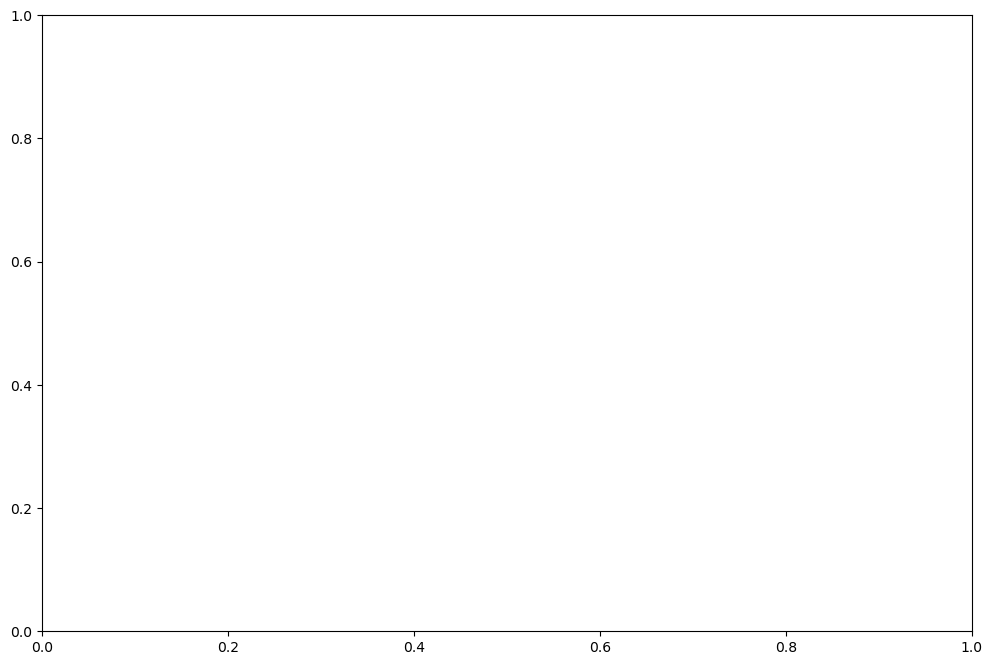

In [14]:
contagem_notifi_uf = dengue.groupby('dengue_notifi_mes')['SG_UF_NOT'].size().reset_index(name='total_notificacoes')
contagem_notifi_uf = contagem_notifi_uf.sort_values(by='total_notificacoes', ascending=False)

plt.figure(figsize=(12, 8))
plt.bar(contagem_notifi_uf['SG_UF_NOT'], contagem_notifi_uf['total_notificacoes'], color='skyblue')
plt.title('Total de Notificações de Dengue por UF')
plt.xlabel('UF')
plt.ylabel('Número de Notificações')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

In [ ]:
dengue['DT_SIN_PRI'] #Data do primeiro sintoma

In [ ]:
dengue['DT_INVEST'] #Data de investigação

In [ ]:
dengue['DT_ENCERRA'] #Informar a data do encerramento do caso